In [9]:
path = "/content/drive/MyDrive/Credit_Risk/"

In [10]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.listdir('/content/drive/MyDrive/')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


['Getting started.pdf',
 'My proj.doc',
 '8810531276777632019-08-05 08_17_41.456_signed.pdf',
 'calls-20200301142322.xml',
 'sms-20200301142322.xml',
 '2041010029-PME-1.pdf',
 '2041010020-ICP-programming assignment 1.pdf',
 '2041010029-DM-Assignment 1.pdf',
 '2041010029-CALC-1 ASSIGNMENT-1.pdf',
 '20401010029-UPM_Assignment_1.pdf',
 'Tarun Jena - 2041010029.pdf',
 '2041010029_ICP_3.pdf',
 '2041010029_ICP_4.pdf',
 '2041010029_ICP_MinorProject_1.zip',
 'TarunJena-2041010029-2041020.pdf',
 '2041010029-expt1.pdf',
 '2041010029_CALC-II_1.pdf',
 '2041010029_DSA_1.pdf',
 '2041010029_CTC_1.pdf',
 '2041010029_CP01.pdf',
 'gpp-xycq-zfh - May 25, 2021.pdf',
 'odc-korx-dxc - May 26, 2021.pdf',
 'tarun jena_ 2041010029.pdf',
 'kfz-zkhj-hzk - May 28, 2021.pdf',
 '2041010029_CTC2.pdf',
 '2041010029_CALC_2.pdf',
 '2041010029_DSA_2.pdf',
 '2041010029_CTC ASSIGNMENT-3.pdf',
 '2041010029_DSA_A3.pdf',
 '2041010029_A3_IGT.pdf',
 '2041010029_A4_IGT.pdf',
 '2041010029_A(3,4)_CALC2.pdf',
 '2041010029_CTC(4).p

In [11]:
path = "/content/drive/MyDrive/Credit_Risk/"

In [12]:
import pandas as pd

path = "/content/drive/MyDrive/Credit_Risk/"

app_df = pd.read_csv(path + "application_train.csv")

app_df.shape
app_df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
app_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [14]:
app_df['TARGET'].value_counts(normalize=True)

,proportion
TARGET,
0,0.919271
1,0.080729


In [15]:
app_df = app_df.drop(columns=['SK_ID_CURR'])

In [16]:
missing_percent = app_df.isnull().mean()

cols_to_drop = missing_percent[missing_percent > 0.4].index

app_df = app_df.drop(columns=cols_to_drop)

In [17]:
target = "TARGET"

X = app_df.drop(columns=[target])
y = app_df[target]

In [18]:
X = pd.get_dummies(X, drop_first=True)

In [19]:
X = X.fillna(X.median())

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
from xgboost import XGBClassifier

model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:33:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [22]:
from sklearn.metrics import roc_auc_score

y_pred = model.predict_proba(X_test)[:, 1]

roc_auc_score(y_test, y_pred)

np.float64(0.7451960183066987)

In [23]:
app_df = pd.read_csv(path + "application_train.csv")

In [24]:
bureau_df = pd.read_csv(path + "bureau.csv")

bureau_df.shape
bureau_df.head()

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


In [25]:
bureau_df.columns

Index(['SK_ID_CURR', 'SK_ID_BUREAU', 'CREDIT_ACTIVE', 'CREDIT_CURRENCY',
       'DAYS_CREDIT', 'CREDIT_DAY_OVERDUE', 'DAYS_CREDIT_ENDDATE',
       'DAYS_ENDDATE_FACT', 'AMT_CREDIT_MAX_OVERDUE', 'CNT_CREDIT_PROLONG',
       'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_LIMIT',
       'AMT_CREDIT_SUM_OVERDUE', 'CREDIT_TYPE', 'DAYS_CREDIT_UPDATE',
       'AMT_ANNUITY'],
      dtype='object')

In [26]:
bureau_agg = bureau_df.groupby('SK_ID_CURR').agg({
    'AMT_CREDIT_SUM': 'sum',
    'AMT_CREDIT_SUM_DEBT': 'sum',
    'DAYS_CREDIT': 'mean'
}).reset_index()

In [27]:
bureau_agg['DEBT_TO_CREDIT_RATIO'] = (
    bureau_agg['AMT_CREDIT_SUM_DEBT'] / bureau_agg['AMT_CREDIT_SUM']
)

In [28]:
app_df = app_df.drop(columns=['SK_ID_CURR'])

missing_percent = app_df.isnull().mean()
cols_to_drop = missing_percent[missing_percent > 0.4].index
app_df = app_df.drop(columns=cols_to_drop)

In [29]:
X = app_df.drop(columns=['TARGET'])
y = app_df['TARGET']

In [30]:
X = pd.get_dummies(X, drop_first=True)

In [31]:
X = X.fillna(X.median())

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [33]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [34]:
from sklearn.metrics import roc_auc_score

y_pred = model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_pred)
roc_auc

np.float64(0.754216038211535)

In [35]:
!pip install shap

In [37]:
X_train.dtypes.value_counts()

,count
bool,112
int64,39
float64,20


In [38]:
X_train = X_train.astype(float)
X_test = X_test.astype(float)

In [39]:
import shap

explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

100%|===================| 61472/61503 [19:01<00:00]       

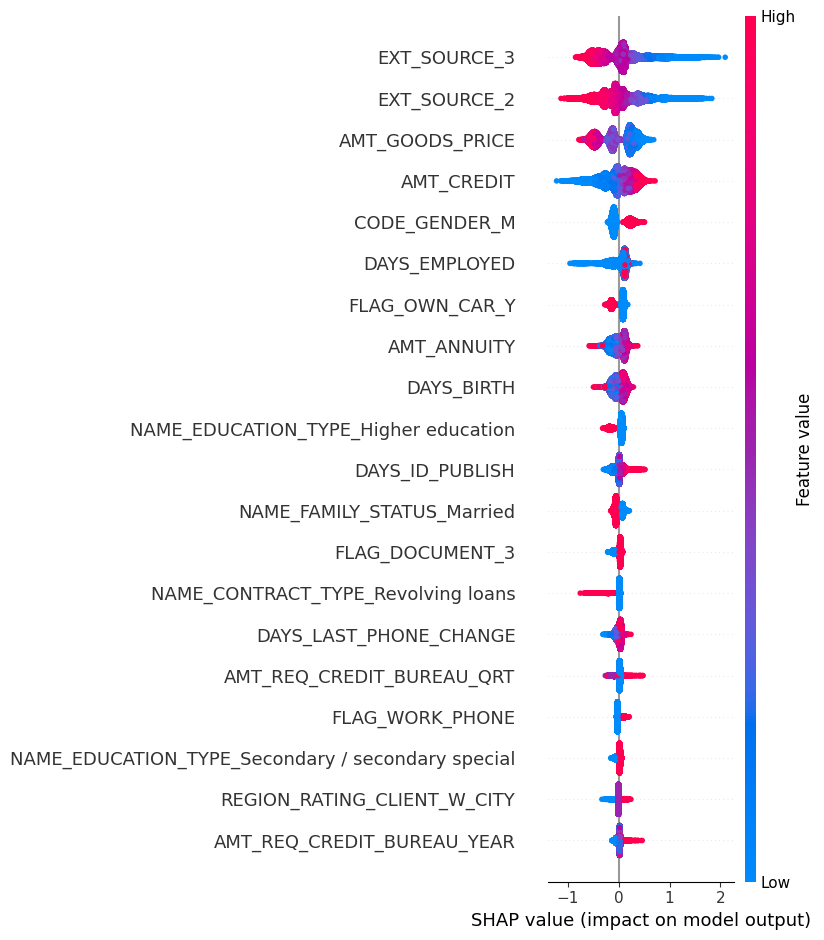

In [40]:
shap.summary_plot(shap_values, X_test)

In [41]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 31.8 MB/s eta 0:00:00


In [44]:
%%writefile /content/drive/MyDrive/Credit_Risk/app.py

import streamlit as st
import pandas as pd
import shap
import pickle

st.title("Credit Risk Decision System")

st.write("This is your ML app 🚀")

Overwriting /content/drive/MyDrive/Credit_Risk/app.py


In [45]:
import pickle

pickle.dump(model, open("/content/drive/MyDrive/Credit_Risk/model.pkl", "wb"))

In [46]:
X_test.iloc[[0]].to_csv("/content/drive/MyDrive/Credit_Risk/sample_input.csv", index=False)

In [48]:
%%writefile /content/drive/MyDrive/Credit_Risk/app.py

import streamlit as st
import pandas as pd
import shap
import pickle

st.title("💳 Credit Risk Decision System")

model = pickle.load(open("model.pkl", "rb"))

data = pd.read_csv("sample_input.csv")

st.write(data)

prediction = model.predict_proba(data)[0][1]

st.write(f"Probability of Default: {prediction:.2f}")

Overwriting /content/drive/MyDrive/Credit_Risk/app.py
